# P1 · Read tensor axes

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.2 · Read tensor axes

A shape gives axis lengths; axis names explain what those lengths mean.

**Prerequisites:** What a tensor contains

**Predict:** How many axes remain after selecting x[0,1] from [2,2,3,2]?

**Mental model:** Four-dimensional attention tensors are easier to read as four questions. Which batch example, which head, which token, and which feature are you selecting?

<a id="pytorch-shapes"></a>

<a data-compat-cell="p1-shapes-indexing-and-slicing"></a>

### Why this operation exists

Four-dimensional attention tensors are easier to read as four questions. Which batch example, which head, which token, and which feature are you selecting?

The shape gives how many answers each question permits. It does not name the questions, so keep axis labels beside the numbers.

Select one axis at a time. Each integer selection removes that axis and leaves the remaining questions to be answered.

A scalar has no remaining axes, although it still holds one value. Zero axes do not mean zero elements.

Rank here means the number of tensor axes. This usage is different from the mathematical rank of a matrix.

### Follow the values

Arrange the integers zero through twenty-three into two batches, two heads, three tokens and two features. Every coordinate has an identifiable value.

Select the first batch. Twelve values remain, organized as two heads with three tokens of two features each.

Select head one inside that batch. Its three token vectors contain six values: six through eleven.

Select token two from that head. Its feature vector contains ten and eleven.

Select feature zero and obtain the scalar ten. Switch batches and repeat the coordinates: the selected value becomes twenty-two while the interpretation stays the same.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 2, 3, 2)
show("[batch, head, token, feature]", x)
b = 1 if change else 0
show("Select a batch: [head, token, feature]", x[b])
show("Select a head: [token, feature]", x[b, 1])
show("Select a token: [feature]", x[b, 1, 2])
show("Select a feature: scalar", x[b, 1, 2, 0])

[batch, head, token, feature]: [[[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]], [[[12, 13], [14, 15], [16, 17]], [[18, 19], [20, 21], [22, 23]]]]
  shape [2, 2, 3, 2] · torch.int64 · cpu
Select a batch: [head, token, feature]: [[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]]
  shape [2, 3, 2] · torch.int64 · cpu
Select a head: [token, feature]: [[6, 7], [8, 9], [10, 11]]
  shape [3, 2] · torch.int64 · cpu
Select a token: [feature]: [10, 11]
  shape [2] · torch.int64 · cpu
Select a feature: scalar: 10
  shape [] · torch.int64 · cpu


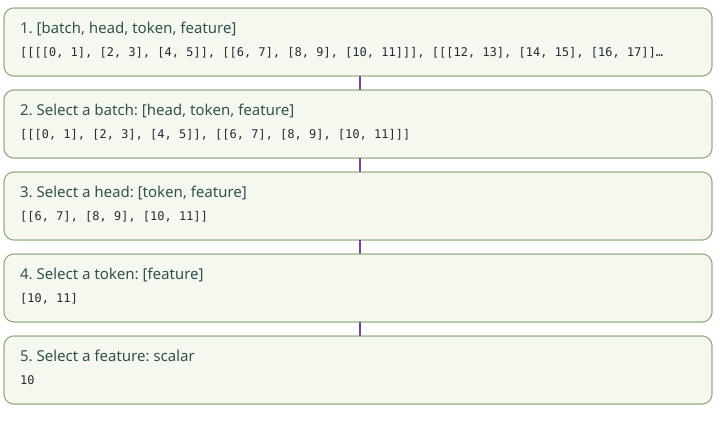

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

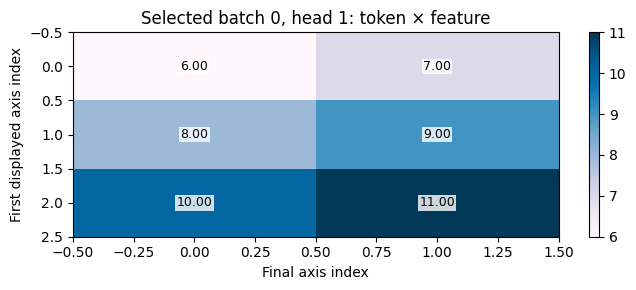

In [5]:
image = (x[0,1].float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Selected batch 0, head 1: token × feature'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

Arange creates unique values so rearrangement mistakes stay visible. Reshape arranges them in the requested four-axis layout.

Unpack x dot shape into batch, heads, tokens and features when you need named sizes. Check that those names match the operation's actual convention.

An integer index removes an axis. A length-one slice keeps an axis, which can matter when later broadcasting expects it.

Negative axis numbers count from the end. The final feature axis is axis minus one, and the token axis is minus two in this layout.

Use shape assertions at important boundaries. They document the interface, but also inspect coordinates when an incorrect permutation could preserve the same shape.

### Change one thing

**Select batch 1 instead of batch 0**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(24).reshape(2, 2, 3, 2)
show("[batch, head, token, feature]", x)
b = 1 if change else 0
show("Select a batch: [head, token, feature]", x[b])
show("Select a head: [token, feature]", x[b, 1])
show("Select a token: [feature]", x[b, 1, 2])
show("Select a feature: scalar", x[b, 1, 2, 0])

[batch, head, token, feature]: [[[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]], [[[12, 13], [14, 15], [16, 17]], [[18, 19], [20, 21], [22, 23]]]]
  shape [2, 2, 3, 2] · torch.int64 · cpu
Select a batch: [head, token, feature]: [[[12, 13], [14, 15], [16, 17]], [[18, 19], [20, 21], [22, 23]]]
  shape [2, 3, 2] · torch.int64 · cpu
Select a head: [token, feature]: [[18, 19], [20, 21], [22, 23]]
  shape [3, 2] · torch.int64 · cpu
Select a token: [feature]: [22, 23]
  shape [2] · torch.int64 · cpu
Select a feature: scalar: 22
  shape [] · torch.int64 · cpu


### A useful distinction

A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.

### ✋ Your turn

For x shaped [2,2,3,2], put tuple(x[0,1].shape) in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (3,2), 'A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
x = torch.arange(24).reshape(2,2,3,2)
answer = tuple(x[0,1].shape)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == (3,2), 'A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.'
    print("✓ right:", answer)

✓ right: (3, 2)


### Reconnect to the transformer

Our tiny transformer uses two heads, each with fourteen features. A batch with four token positions has query shape batch by two by four by fourteen.

Attention scores replace the final feature axis with a key-position axis. Their last two axes describe query positions and key positions.

Phyll uses more heads and features, but these axis meanings transfer. Its temporary fused QKV representation also introduces a fifth axis selecting query, key or value.

Bigger tensors do not require a different mental model. Select a small slice and preserve the axis labels when inspecting it.

Next, compare indexing operations that keep an axis with operations that remove it.

```python
B, T, C = x.shape
q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** How many axes remain after selecting x[0,1] from [2,2,3,2]?

<details><summary>Check your explanation</summary>

2. A tensor’s shape does not encode axis names. Two equal-sized axes can still have different meanings.

</details>